# IBM Telco Customer Churn: Exploratory Data Analysis & Business Insights
**Author:** Tarush Nandan  
*Strategic Portfolio Project | Business Intelligence & Data Analysis*

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
!pip install openpyxl


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
df = pd.read_excel('Telco_customer_churn.xlsx')

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

In [4]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [5]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
print(df['Total Charges'].dtype)

float64


In [6]:
df.head(3)

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved


In [7]:
print(df['Total Charges'].isnull().sum())

11


In [8]:
print(df.duplicated().sum())

0


In [9]:
print(df['CustomerID'].duplicated().sum())

0


In [10]:
print(df[df['Total Charges'].isnull()][['Tenure Months', 'Monthly Charges', 'Total Charges']])

      Tenure Months  Monthly Charges  Total Charges
2234              0            52.55            NaN
2438              0            20.25            NaN
2568              0            80.85            NaN
2667              0            25.75            NaN
2856              0            56.05            NaN
4331              0            19.85            NaN
4687              0            25.35            NaN
5104              0            20.00            NaN
5719              0            19.70            NaN
6772              0            73.35            NaN
6840              0            61.90            NaN


In [11]:
df['Total Charges'] = df['Total Charges'].fillna(0)

In [12]:
print(df['Total Charges'].isnull().sum())

0


In [13]:
print(df.groupby('Churn Value')['Tenure Months'].mean())

Churn Value
0    37.569965
1    17.979133
Name: Tenure Months, dtype: float64


In [14]:
import seaborn as sns

In [15]:
Churn_counts = df['Churn Value'].value_counts(normalize= True) * 100
print(Churn_counts)

Churn Value
0    73.463013
1    26.536987
Name: proportion, dtype: float64


In [16]:
## Retained (0): ~73.5%
##Churned (1): ~26.5%

In [17]:
Contract_churn = df.groupby('Contract')['Churn Value'].mean() * 100
print(Contract_churn)

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn Value, dtype: float64


In [18]:
## Month-to-month contracts: ~42.7% churn rate
##One year contracts: ~11.3% churn rate
##Two year contracts: ~2.8% churn rate

## Compared to our 26.5% overall baseline, month-to-month customers are churning at an alarming rate
## (almost 43%), while customers on two-year agreements are practically rock-solid at under 3%.

In [19]:
Payment_churn = df.groupby('Payment Method')['Churn Value'].mean() * 100
print(Payment_churn.sort_values(ascending=False))

Payment Method
Electronic check             45.285412
Mailed check                 19.106700
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Name: Churn Value, dtype: float64


In [20]:
##Electronic check: ~45.3% churn rate
## Mailed check: ~19.1% churn rate
##Bank transfer (automatic): ~16.7% churn rate
##Credit card (automatic): ~15.2% churn rate
## Customers using Electronic check are churning at more than double the rate of automatic payment methods or mailed checks.
## Automatic payments (credit card and bank transfer) anchor customers much better, 
## likely because automatic billing reduces the friction of manual payments and prevents accidental payment lapses.

In [21]:
Churn_Reason = df.groupby('Churn Reason')['Churn Value'].mean() * 100
print(Churn_Reason)

Churn Reason
Attitude of service provider                 100.0
Attitude of support person                   100.0
Competitor had better devices                100.0
Competitor made better offer                 100.0
Competitor offered higher download speeds    100.0
Competitor offered more data                 100.0
Deceased                                     100.0
Don't know                                   100.0
Extra data charges                           100.0
Lack of affordable download/upload speed     100.0
Lack of self-service on Website              100.0
Limited range of services                    100.0
Long distance charges                        100.0
Moved                                        100.0
Network reliability                          100.0
Poor expertise of online support             100.0
Poor expertise of phone support              100.0
Price too high                               100.0
Product dissatisfaction                      100.0
Service dissatisfa

In [22]:
Churn_Reason_counts = df['Churn Reason'].value_counts()
print(Churn_Reason_counts)

Churn Reason
Attitude of support person                   192
Competitor offered higher download speeds    189
Competitor offered more data                 162
Don't know                                   154
Competitor made better offer                 140
Attitude of service provider                 135
Competitor had better devices                130
Network reliability                          103
Product dissatisfaction                      102
Price too high                                98
Service dissatisfaction                       89
Lack of self-service on Website               88
Extra data charges                            57
Moved                                         53
Limited range of services                     44
Lack of affordable download/upload speed      44
Long distance charges                         44
Poor expertise of phone support               20
Poor expertise of online support              19
Deceased                                       6
Name: c

### Top Complaint: "Attitude of support person" (192 customers) and various competitor offers
### (higher speeds, more data, better overall offers) are pulling customers away in large numbers.

### Support Quality vs. Price: Interestingly, poor support interactions and aggressive competitor poaching rank higher as direct exit reasons than
### "Price too high" (98 customers).

In [23]:
print(df.groupby('Churn Value')['Monthly Charges'].describe())

              count       mean        std    min    25%     50%   75%     max
Churn Value                                                                  
0            5174.0  61.265124  31.092648  18.25  25.10  64.425  88.4  118.75
1            1869.0  74.441332  24.666053  18.85  56.15  79.650  94.2  118.35


In [24]:
## Retained Customers (0): Mean monthly charge of ~$61.27 (with a median/50% of ~$64.43)
## Churned Customers (1): Mean monthly charge of ~$74.44 (with a median/50% of ~$79.65)

### Customers who churn are paying significantly higher monthly bills on average than those who stay. Look closely at the 25th percentile too: for churned customers, 25% of them are paying at least $56.15, whereas for retained customers, the 25th percentile starts way down at $25.10.

### This confirms that higher monthly costs create a strong financial pressure point, making customers far more sensitive to service issues or competitor offers.

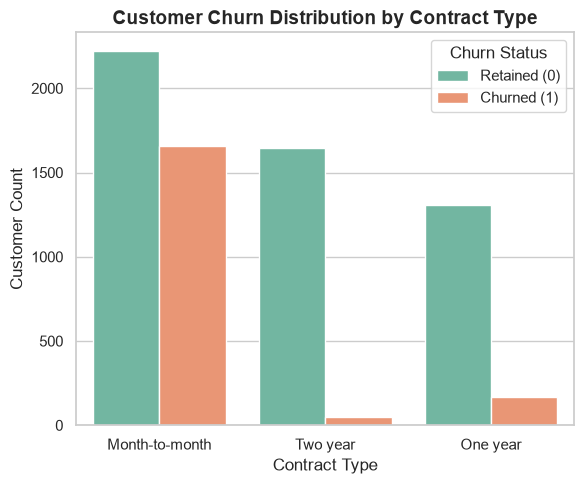

In [25]:
## Contract vs Churn
sns.set_theme(style="whitegrid")
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x='Contract', hue='Churn Value', palette='Set2')
plt.title('Customer Churn Distribution by Contract Type', fontsize=14, fontweight='bold')
plt.xlabel('Contract Type', fontsize=12)
plt.ylabel('Customer Count', fontsize=12)
plt.legend(title='Churn Status', labels=['Retained (0)', 'Churned (1)'])
plt.savefig('contract_churn.png', bbox_inches='tight', dpi=300)
plt.tight_layout()
plt.show()

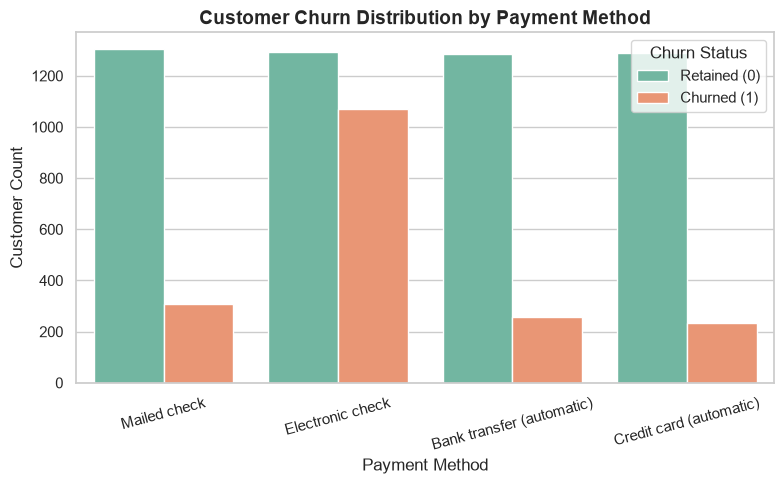

In [26]:
## Payment Method vs Churn
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Payment Method', hue='Churn Value', palette='Set2')
plt.title('Customer Churn Distribution by Payment Method', fontsize=14, fontweight='bold')
plt.xlabel('Payment Method', fontsize=12)
plt.ylabel('Customer Count', fontsize=12)
plt.legend(title='Churn Status', labels=['Retained (0)', 'Churned (1)'])
plt.xticks(rotation=15)
plt.savefig('payment_churn.png', bbox_inches='tight', dpi=300)
plt.tight_layout()
plt.show()

## Executive Summary & Strategic Recommendations

Our exploratory data analysis of the IBM Telco Churn dataset uncovered critical behavioral and financial drivers behind customer attrition. Rather than a random phenomenon, churn is heavily concentrated in specific structural segments.

### Key Insights
* **Baseline Churn Rate:** The overall dataset baseline sits at **26.5%**, providing a benchmark for segment risk analysis.
* **Contract Vulnerability:** Month-to-month subscribers experience an alarming **42.7% churn rate**, compared to just **2.8%** for two-year contract holders. Long-term agreements are the strongest defense against churn.
* **Billing Friction:** Customers paying via **Electronic check** churn at **45.3%**, more than double the rate of automatic payment methods (credit card and bank transfer).
* **Financial Pressure:** Churned customers carry a significantly higher mean monthly charge of 74.44, compared to 61.27 for retained customers, making higher-tier spenders more sensitive to service friction.
* **Qualitative Drivers:** Exit logs reveal that the **"Attitude of support person"** and aggressive **competitor poaching** (offers for higher speeds/better deals) are the primary qualitative reasons customers walk away.

### Actionable Business Recommendations
1. **Drive Long-Term Commitments:** Introduce loyalty discounts or introductory bundling for month-to-month users to transition them into 1-year or 2-year contracts.
2. **Eliminate Billing Friction:** Incentivize customers to move away from electronic checks by offering small bill credits for switching to automatic credit card or bank transfer setups.
3. **Overhaul Support Quality:** Conduct targeted communication and empathy training for customer support teams, as support friction is a major catalyst for customer defection.
4. **Competitive Defense Tiers:** Implement a proactive retention program for customers paying over $75/month who contact support multiple times, ensuring they receive competitive speed upgrades before they are poached by rivals.